# Import Necessary Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Data Preprocessing

In [2]:
!nvidia-smi
from google.colab import drive
drive.mount('/content/drive')

Wed May 15 11:24:08 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA L4                      Off | 00000000:00:03.0 Off |                    0 |
| N/A   48C    P8              12W /  72W |      1MiB / 23034MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [4]:
!pip install unrar

In [5]:
! unrar x /content/drive/MyDrive/AML_coursework.rar

Streaming output truncated to the last 5000 lines.
Extracting  Resized_images_dataset_new/supermarket/00000462.jpg           68%  OK 
Extracting  Resized_images_dataset_new/supermarket/00000463.jpg           68%  OK 
Extracting  Resized_images_dataset_new/supermarket/00000464.jpg           68%  OK 
Extracting  Resized_images_dataset_new/supermarket/00000465.jpg           68%  OK 
Extracting  Resized_images_dataset_new/supermarket/00000466.jpg           68%  OK 
Extracting  Resized_images_dataset_new/supermarket/00000467.jpg           68%  OK 
Extracting  Resized_images_dataset_new/supermarket/00000468.jpg           68%  OK 
Extracting  Resized_images_dataset_new/supermarket/00000469.jpg           68%  OK 
Extracting  Resized_images_dataset_new/supermarket/00000470.jpg           68%  OK 
Extracting  Resized_images_dataset_new/supermarket/00000471.jpg           69%  OK 
Extracting  Resized_images_da

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])


val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229]),
])

# Load and Split the Dataset

In [7]:
dataset_path = "/content/Resized_images_dataset_new"
dataset_full = ImageFolder(dataset_path, transform=train_transform)

train_size = int(0.8 * len(dataset_full))
val_size = len(dataset_full) - train_size
train_dataset, val_dataset = random_split(dataset_full, [train_size, val_size])

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_path = '/content/testset'
test_dataset = ImageFolder("/content/testset", transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=64,shuffle=True)

In [24]:
test_path = '/content/testset'
test_dataset = ImageFolder("/content/testset", transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=64,shuffle=True)

# Model Setup

In [8]:
model = models.resnet34(pretrained=True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Dropout(0,4),
    nn.Linear(256, 40),
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 187MB/s]


ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Training and Validation

In [9]:
#functions for top-k acccuracy
def top_k_accuracy(output, target, k=5):
    with torch.no_grad():
        max_k_preds = torch.topk(output, k, dim=1).indices
        max_k_preds = max_k_preds.t()
        correct = max_k_preds.eq(target.view(1, -1).expand_as(max_k_preds))
        top_k_acc = correct[:k].reshape(-1).float().sum(0, keepdim=True) / target.size(0)
    return top_k_acc

In [10]:
#dictionary of classes and index assigned
classes = test_dataset.class_to_idx
id2classes = { v: k for k, v in classes.items() }

In [35]:
#confusion matrix function
def get_confusion_matrix(labels,predicted):
    labels_on_cpu = [label.tolist() for label in labels]
    predicted_on_cpu = [predict.tolist() for predict in predicted]
    label_list = []
    predicted_list = []
    for lab,pre in zip(labels_on_cpu,predicted_on_cpu):
        label_list.append(id2classes[lab])
        predicted_list.append(id2classes[pre])

    cm = confusion_matrix(label_list,predicted_list)
    return cm,predicted_list,label_list

In [29]:
# function to plot the confusion matrix
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import itertools

def plot_matrix(cm,true_labels,predicted,title):

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix ' + title)
    plt.colorbar()
    tick_marks = np.arange(len(np.unique(true_labels)))
    plt.xticks(tick_marks, np.unique(true_labels))
    plt.yticks(tick_marks, np.unique(true_labels))

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xticks(rotation =90)
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [13]:
# training function block
learning_rate = 0.0001
weight_decay = 0.0005
logs_base_dir = "logs"
writer = SummaryWriter(logs_base_dir,)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = CosineAnnealingLR(optimizer, T_max=10)
criterion = nn.CrossEntropyLoss()

epochs = 8
count = 0
top_k_val_acc = 0.0
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    top_k_val_acc = 0.0
    top_k_val_acc1 = 0.0
    pred = []
    label = []
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validation"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            top_k_val_acc += top_k_accuracy(outputs, labels, k=5).item()
            top_k_val_acc1 += top_k_accuracy(outputs, labels, k=1).item()
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            label.append(labels)
            pred.append(predicted)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * correct / total
    epoch_top_k_val_acc = top_k_val_acc /len(val_loader)
    epoch_top_k_val_acc1 = top_k_val_acc1/len(val_loader)

    print(f'Validation Top-5 Accuracy: {epoch_top_k_val_acc:.4f}')
    print(f'Validation Top-1 Accuracy: {epoch_top_k_val_acc1:.4f}')
    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss}, Val Loss: {val_loss}, Val Acc: {val_acc}%')
    writer.add_scalar('training loss',train_loss,epoch)
    writer.add_scalar('Validation loss',val_loss,epoch)
    writer.add_scalar('validation accuracy',val_acc,epoch)
    writer.add_scalar('Validation Top-5 Accuracy',epoch_top_k_val_acc,epoch)
    writer.add_scalar('Validation Top-1 Accuracy',epoch_top_k_val_acc1,epoch)


    scheduler.step(val_loss)

Validation: 100%|██████████| 63/63 [00:16<00:00,  3.80it/s]
/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:156: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Validation Top-5 Accuracy: 0.6962
Validation Top-1 Accuracy: 0.3584
Epoch 1/8, Train Loss: 2.8036641931533812, Val Loss: 2.2861239531683544, Val Acc: 35.9125%


Validation: 100%|██████████| 63/63 [00:16<00:00,  3.88it/s]


Validation Top-5 Accuracy: 0.7681
Validation Top-1 Accuracy: 0.4325
Epoch 2/8, Train Loss: 1.9787328295707702, Val Loss: 1.9877982764017015, Val Acc: 43.3%


Validation: 100%|██████████| 63/63 [00:16<00:00,  3.85it/s]


...

Validation Top-5 Accuracy: 0.8258
Validation Top-1 Accuracy: 0.5043
Epoch 6/8, Train Loss: 1.1558156445026397, Val Loss: 1.7486726367284382, Val Acc: 50.45%


Validation: 100%|██████████| 63/63 [00:16<00:00,  3.87it/s]


Validation Top-5 Accuracy: 0.8220
Validation Top-1 Accuracy: 0.5050
Epoch 7/8, Train Loss: 1.017983155965805, Val Loss: 1.787928513118199, Val Acc: 50.5125%


Validation: 100%|██████████| 63/63 [00:16<00:00,  3.79it/s]

Validation Top-5 Accuracy: 0.8162
Validation Top-1 Accuracy: 0.5124
Epoch 8/8, Train Loss: 0.893195835351944, Val Loss: 1.838965994971139, Val Acc: 51.225%


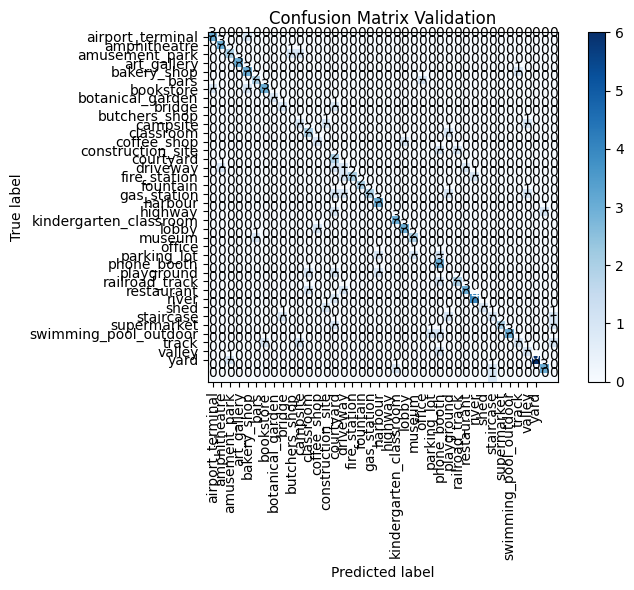

                        precision    recall  f1-score   support

      airport_terminal       0.75      0.75      0.75         4
          amphitheatre       0.75      1.00      0.86         3
        amusement_park       0.67      0.50      0.57         4
           art_gallery       1.00      1.00      1.00         3
           bakery_shop       0.60      0.75      0.67         4
                  bars       0.67      0.67      0.67         3
             bookstore       0.75      0.60      0.67         5
      botanical_garden       1.00      1.00      1.00         1
                bridge       0.50      0.50      0.50         2
          bus_interior       0.00      0.00      0.00         0
         butchers_shop       0.33      0.33      0.33         3
              campsite       0.50      0.67      0.57         3
             classroom       0.50      0.50      0.50         2
           coffee_shop       0.00      0.00      0.00         2
     construction_site       0.22      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

In [53]:
# Printing the plot for validation confusion matrix for one batch
for pre,lab in zip(pred,label):
    cm,pred_list,label_list = get_confusion_matrix(lab,pre)
    plot_matrix(cm,label_list,pred_list,'Validation')
    print(classification_report(label_list,pred_list))
    break

In [17]:
#Saving the model file
save_path = 'resnet34_model_epoch_new.pth'
torch.save(model.state_dict(), save_path)

In [18]:
checkpoint = torch.load('resnet34_model_epoch_new.pth')

# Testing

In [51]:
#Testing Block
model.eval()
test_loss = 0.0
correct = 0
total = 0
top_k_val_acc = 0.0
pred_list = []
label_test =[]
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        top_k_val_acc += top_k_accuracy(outputs, labels, k=5).item()
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        pred_list.append(predicted)
        label_test.append(labels)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f'Test Loss: {test_loss/len(test_loader)}, Test Accuracy: {test_acc}%')
epoch_top_k_val_acc = top_k_val_acc / len(test_loader)
print(f'Test Top-5 Accuracy: {epoch_top_k_val_acc:.4f}')

Test Loss: 1.1056806870869227, Test Accuracy: 66.90821256038647%
Test Top-5 Accuracy: 0.9372


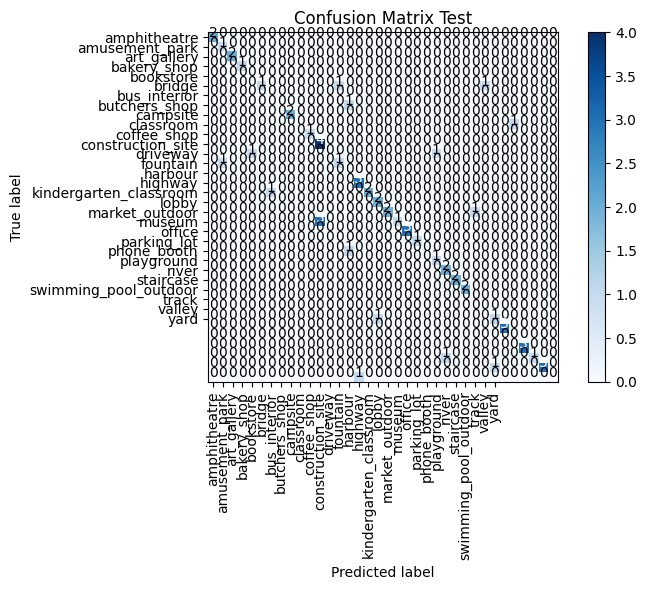

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

                        precision    recall  f1-score   support

          amphitheatre       1.00      1.00      1.00         2
        amusement_park       0.50      1.00      0.67         1
           art_gallery       1.00      1.00      1.00         2
           bakery_shop       1.00      1.00      1.00         1
                  bars       0.00      0.00      0.00         0
             bookstore       1.00      0.33      0.50         3
      botanical_garden       0.00      0.00      0.00         0
                bridge       0.00      0.00      0.00         1
          bus_interior       1.00      1.00      1.00         2
         butchers_shop       0.00      0.00      0.00         1
              campsite       1.00      1.00      1.00         1
             classroom       0.57      1.00      0.73         4
           coffee_shop       0.00      0.00      0.00         2
     construction_site       0.50      0.50      0.50         2
             courtyard       0.00      

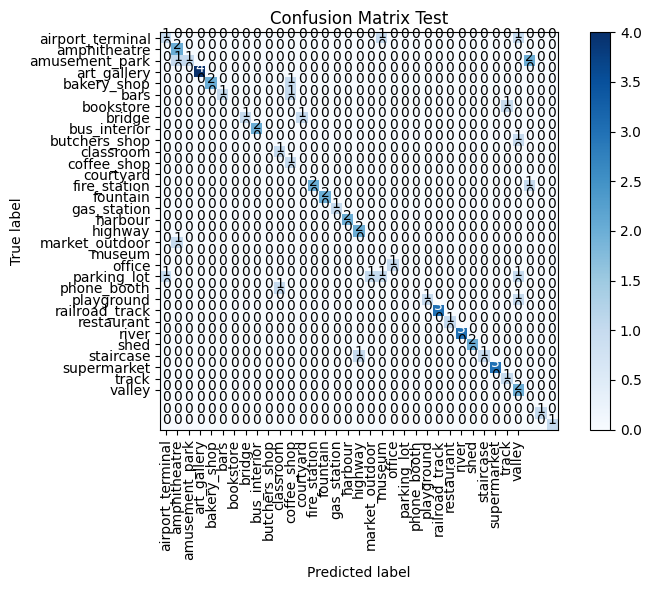

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

                       precision    recall  f1-score   support

     airport_terminal       0.50      0.33      0.40         3
         amphitheatre       0.50      1.00      0.67         2
       amusement_park       1.00      0.25      0.40         4
          art_gallery       1.00      1.00      1.00         4
          bakery_shop       1.00      0.67      0.80         3
                 bars       1.00      0.50      0.67         2
            bookstore       0.00      0.00      0.00         1
               bridge       1.00      0.50      0.67         2
         bus_interior       1.00      1.00      1.00         2
        butchers_shop       0.00      0.00      0.00         1
            classroom       0.50      1.00      0.67         1
          coffee_shop       0.33      1.00      0.50         1
    construction_site       0.00      0.00      0.00         0
            courtyard       1.00      0.67      0.80         3
         fire_station       1.00      1.00      1.00  

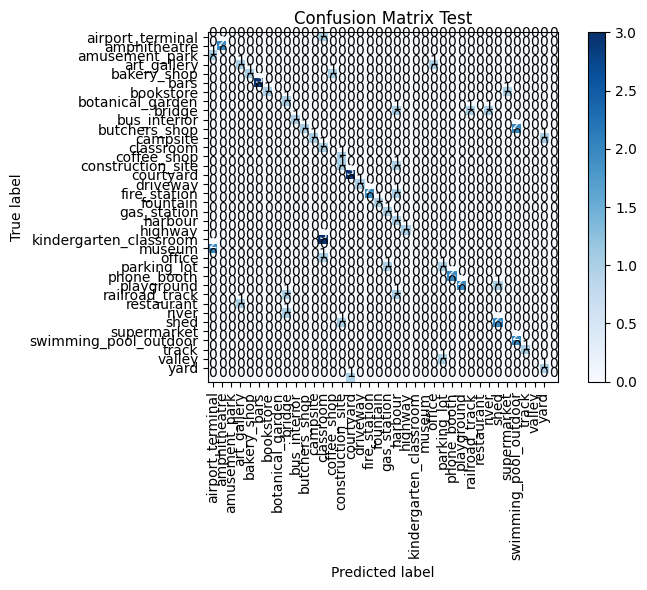

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

                        precision    recall  f1-score   support

      airport_terminal       0.00      0.00      0.00         1
          amphitheatre       1.00      1.00      1.00         2
        amusement_park       0.00      0.00      0.00         1
           art_gallery       0.50      0.50      0.50         2
           bakery_shop       1.00      0.50      0.67         2
                  bars       1.00      1.00      1.00         3
             bookstore       1.00      0.50      0.67         2
      botanical_garden       0.00      0.00      0.00         1
                bridge       0.00      0.00      0.00         3
          bus_interior       1.00      1.00      1.00         1
         butchers_shop       1.00      0.33      0.50         3
              campsite       1.00      0.50      0.67         2
             classroom       0.17      1.00      0.29         1
           coffee_shop       0.00      0.00      0.00         1
     construction_site       0.33      

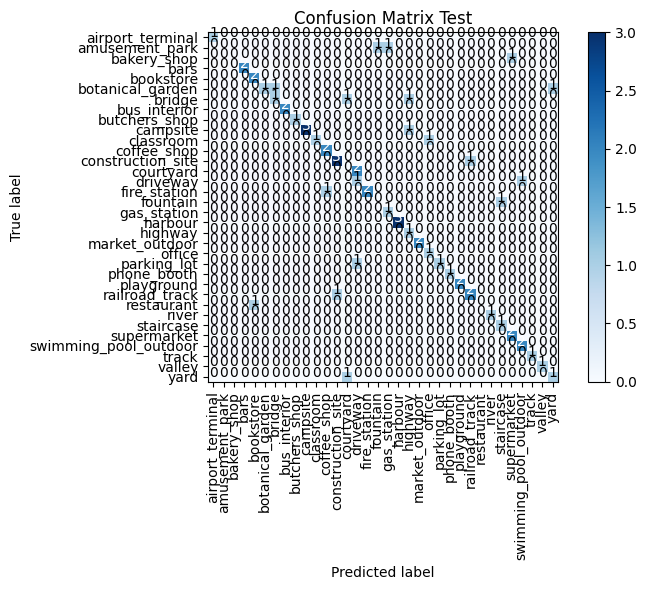

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                       precision    recall  f1-score   support

     airport_terminal       1.00      1.00      1.00         1
       amusement_park       0.00      0.00      0.00         2
          bakery_shop       0.00      0.00      0.00         1
                 bars       1.00      1.00      1.00         2
            bookstore       0.67      1.00      0.80         2
     botanical_garden       1.00      0.33      0.50         3
               bridge       0.50      0.33      0.40         3
         bus_interior       1.00      1.00      1.00         2
        butchers_shop       1.00      1.00      1.00         1
             campsite       1.00      0.75      0.86         4
            classroom       1.00      0.50      0.67         2
          coffee_shop       0.67      1.00      0.80         2
    construction_site       0.75      0.75      0.75         4
            courtyard       0.00      0.00      0.00         2
             driveway       0.25      0.50      0.33  

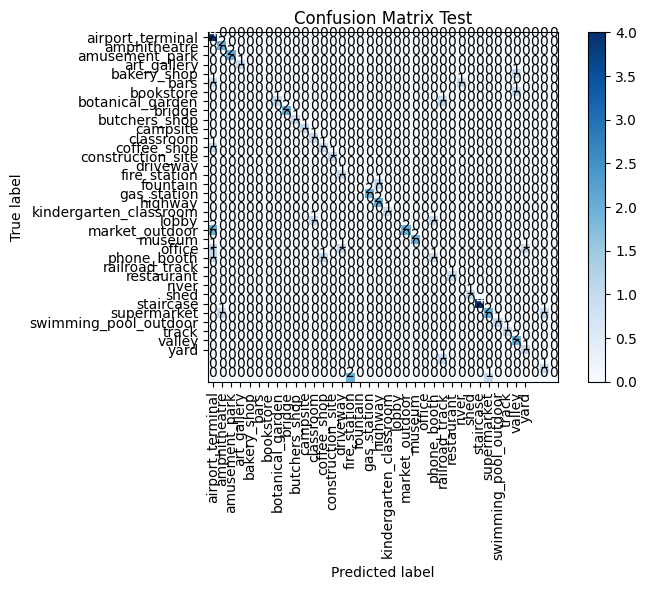

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

                        precision    recall  f1-score   support

      airport_terminal       0.40      1.00      0.57         4
          amphitheatre       0.67      1.00      0.80         2
        amusement_park       1.00      1.00      1.00         2
           art_gallery       1.00      1.00      1.00         1
           bakery_shop       0.00      0.00      0.00         1
                  bars       0.00      0.00      0.00         2
             bookstore       0.00      0.00      0.00         1
      botanical_garden       1.00      0.50      0.67         2
                bridge       1.00      1.00      1.00         2
         butchers_shop       1.00      1.00      1.00         1
              campsite       1.00      1.00      1.00         1
             classroom       0.50      1.00      0.67         1
           coffee_shop       0.50      0.50      0.50         2
     construction_site       1.00      1.00      1.00         1
             courtyard       0.00      

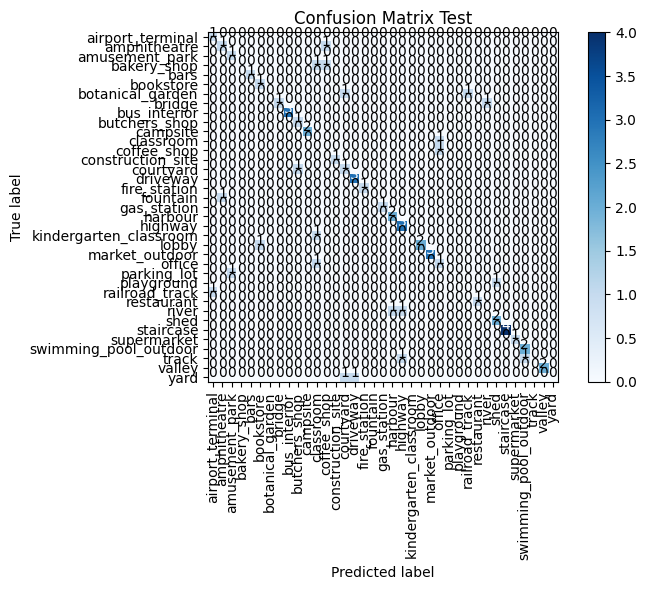

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                        precision    recall  f1-score   support

      airport_terminal       0.50      1.00      0.67         1
          amphitheatre       0.50      0.50      0.50         2
        amusement_park       0.50      1.00      0.67         1
           bakery_shop       0.00      0.00      0.00         2
                  bars       1.00      1.00      1.00         1
             bookstore       0.50      1.00      0.67         1
      botanical_garden       0.00      0.00      0.00         2
                bridge       1.00      0.50      0.67         2
          bus_interior       1.00      1.00      1.00         3
         butchers_shop       0.50      1.00      0.67         1
              campsite       1.00      1.00      1.00         2
             classroom       0.00      0.00      0.00         1
           coffee_shop       0.00      0.00      0.00         1
     construction_site       1.00      1.00      1.00         1
             courtyard       0.33      

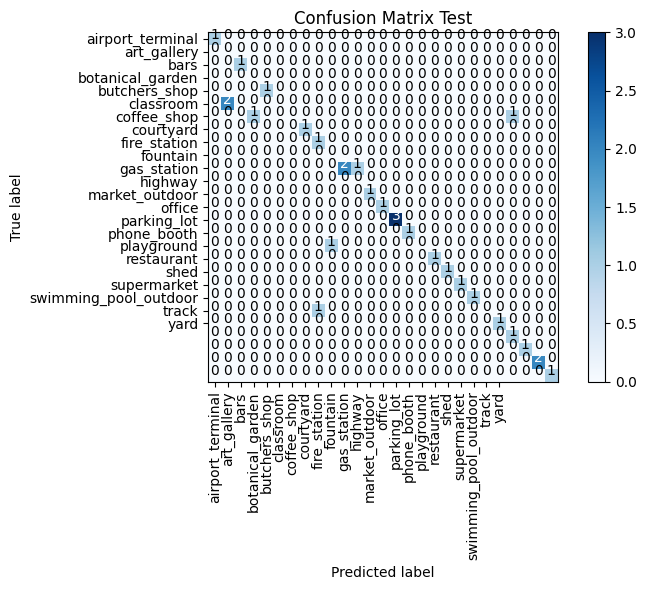

                       precision    recall  f1-score   support

     airport_terminal       1.00      1.00      1.00         1
       amusement_park       0.00      0.00      0.00         0
          art_gallery       1.00      1.00      1.00         1
          bakery_shop       0.00      0.00      0.00         0
                 bars       1.00      1.00      1.00         1
     botanical_garden       0.00      0.00      0.00         2
        butchers_shop       0.00      0.00      0.00         2
            classroom       1.00      1.00      1.00         1
          coffee_shop       0.50      1.00      0.67         1
    construction_site       0.00      0.00      0.00         0
            courtyard       1.00      0.67      0.80         3
             driveway       0.00      0.00      0.00         0
         fire_station       1.00      1.00      1.00         1
             fountain       1.00      1.00      1.00         1
          gas_station       1.00      1.00      1.00  

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.

In [52]:
# Printing the confusion matrix
from sklearn.metrics import classification_report

for lab,pre in zip(label_test,pred_list):
    cm,pred_list,label_list = get_confusion_matrix(lab,pre)
    plot_matrix(cm,label_list,pred_list,'Test')
    print(classification_report(label_list,pred_list))


In [ ]:
# writing and starting the tensorboard server
writer.flush()
writer.close()
!tensorboard --logdir /content/logs --port 6006